# Model Explainability with SHAP — Task 3

**Objective.** Interpret the Task-2 selected model (XGBoost + `scale_pos_weight`) and turn the interpretation into business recommendations.

**Structure**

1. Built-in (gain) feature importance — top 10.
2. SHAP global importance — beeswarm summary + mean |SHAP| bar.
3. SHAP force / waterfall plots for a **true positive**, a **false positive** and a **false negative**.
4. Gain vs SHAP: where the two rankings disagree, and why.
5. Effect shape — *where* each driver flips sign, which is what makes a threshold actionable.
6. Candidate rules scored against the labels, then recommendations.

**Why both importance measures.** Gain answers *"which features did the trees split on most profitably?"* — global, unsigned, structural. SHAP answers *"how much did this feature move **this** prediction, and which way?"* Values are additive per prediction, so they support a global ranking *and* per-transaction explanations. Where the two disagree, the disagreement is itself the finding.

Reusable logic lives in [`src/explainability.py`](../src/explainability.py); the batch runner that writes every figure is [`scripts/explain_models.py`](../scripts/explain_models.py).

In [1]:
import sys
from pathlib import Path

# Make the project root importable so `from src import ...` resolves.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

from src import config
config.ensure_dirs()
FIG = config.FIGURES_DIR


In [2]:
import joblib
import shap
from src import modeling as md, evaluation as ev, explainability as xai

print('shap', shap.__version__)
artifact = joblib.load(config.MODELS_DIR / 'fraud_selected.joblib')
pipe, threshold = artifact['pipeline'], artifact['threshold']
print('model:', artifact.get('model_key'), '| threshold:', round(threshold, 4))
print('steps:', list(dict(pipe.steps)))

shap 0.51.0
model: xgb_weighted | threshold: 0.8956
steps: ['preprocess', 'clf']


## 1. Rebuild the Task-2 test split

Same `random_state`, so these are the exact rows the model was scored on in Task 2 — the explanations describe the reported performance, not a different sample.

In [3]:
features = list(pipe.named_steps['preprocess'].feature_names_in_)
fraud = pd.read_csv(config.FRAUD_FEATURES)
X, y = md.split_features_target(fraud, config.FRAUD_TARGET, features)
for c in md.FRAUD_CATEGORICAL_COLS:
    X[c] = X[c].astype(str)
X_train, X_test, y_train, y_test = md.stratified_split(X, y, test_size=0.2)
scores = ev.predict_proba_positive(pipe, X_test)
print(f'test set: {len(X_test):,} rows, {int(y_test.sum()):,} frauds')
pd.Series(ev.classification_metrics(y_test, scores, threshold)).to_frame('selected model').round(4)

test set: 30,223 rows, 2,830 frauds


,selected model
auc_pr,0.7141
f1,0.6900
precision,0.9993
recall,0.5269
roc_auc,0.8387
threshold,0.8956
tn,27392.0000
fp,1.0000
fn,1339.0000
tp,1491.0000


## 2. Built-in feature importance (baseline)

XGBoost's `feature_importances_` uses **gain**: the average improvement in the split criterion each feature delivered. It is unsigned — a high-gain feature could push scores up, down, or both.

,gain,weight
device_transaction_count,0.5229,0.1949
device_user_count,0.1707,0.0285
time_since_signup,0.1546,0.2203
device_velocity_24h,0.0195,0.0639
source_Direct,0.0177,0.0277
browser_IE,0.0064,0.0031
country_Italy,0.0058,0.0054
browser_Chrome,0.0055,0.0054
browser_Safari,0.0054,0.0046
browser_Opera,0.0053,0.0008


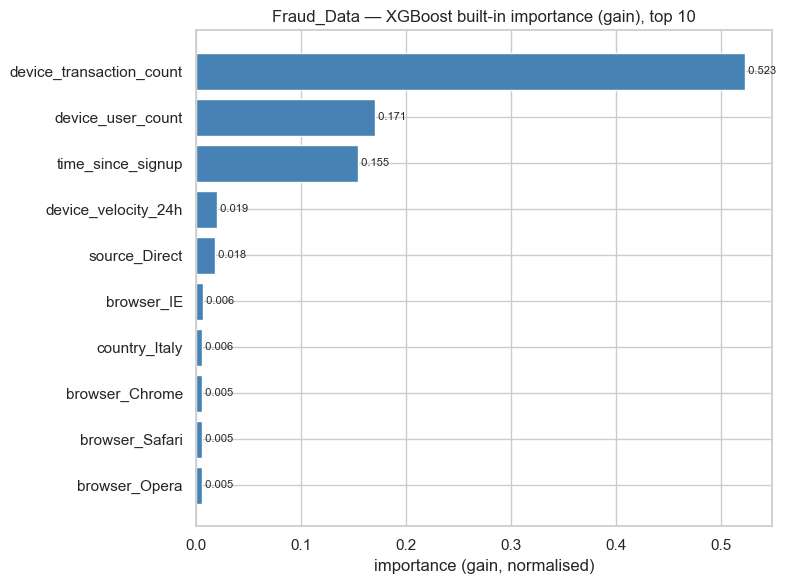

top 3 features hold 84.8% of total gain


In [4]:
gain = xai.builtin_importance(pipe, importance_type='gain')
weight = xai.builtin_importance(pipe, importance_type='weight')
display(gain.head(10).rename('gain').to_frame().join(weight.rename('weight')).round(4))
xai.plot_builtin_importance(gain, 10,
    'Fraud_Data — XGBoost built-in importance (gain), top 10',
    FIG / 'fraud_builtin_importance.png')
plt.show()
print(f'top 3 features hold {gain.head(3).sum():.1%} of total gain')

## 3. SHAP — global explanation

`TreeExplainer` is **exact** for tree ensembles (no sampling approximation). Values are in log-odds, additive: they sum to the model's margin minus the base value.

In the beeswarm each dot is one transaction — x is that feature's SHAP value (right = pushed toward fraud), colour is the feature's own value. This is the plot that reveals whether *high* or *low* values drive fraud, which the gain bar chart cannot show.

In [5]:
expl = xai.shap_explanation(pipe, X_test)
print('SHAP values:', expl.values.shape, '| base value (log-odds):',
      round(float(expl.base_values[0]), 4))
shap_imp = xai.shap_importance(expl)
signed = xai.signed_shap_direction(expl)
display(shap_imp.head(10).rename('mean_abs_shap').to_frame()
        .join(signed.rename('mean_signed_shap')).round(4))

SHAP values: (30223, 34) | base value (log-odds): 0.0124


,mean_abs_shap,mean_signed_shap
device_transaction_count,0.9358,-0.6005
time_since_signup,0.4322,-0.0195
device_velocity_24h,0.1136,0.0853
device_user_count,0.0776,-0.0506
purchase_value,0.0319,-0.0032
source_Direct,0.0267,-0.0034
day_of_week,0.0255,-0.0019
age,0.0230,-0.0026
hour_of_day,0.0177,-0.0012
source_SEO,0.0142,-0.0002


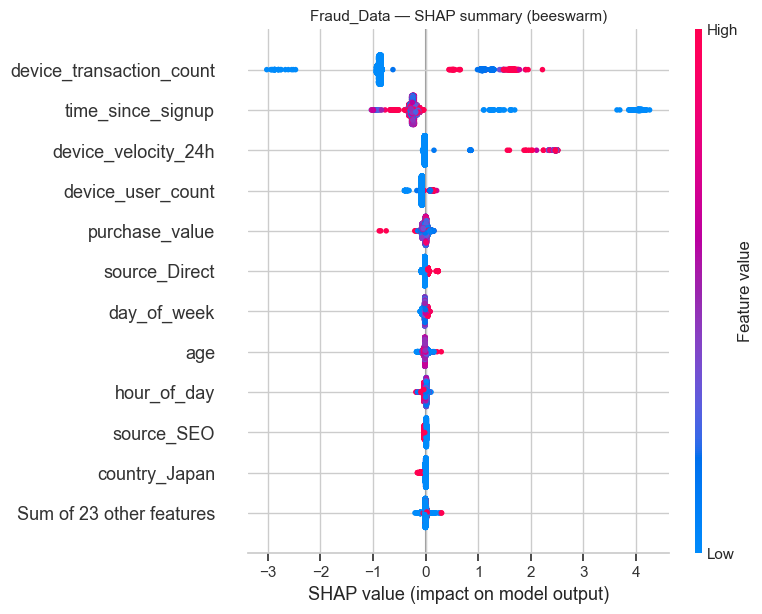

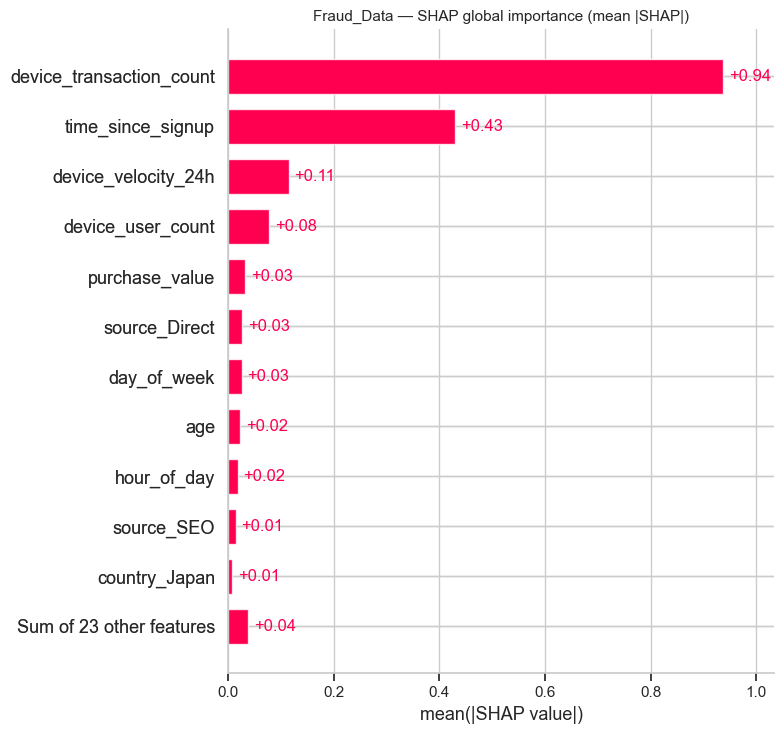

In [6]:
# Beeswarm on a 5k subsample — 30k overlapping dots is unreadable and
# the ranking it displays is unchanged.
plot_expl = xai.shap_explanation(pipe, X_test, sample_size=5000)
xai.plot_shap_summary(plot_expl, 12,
    'Fraud_Data — SHAP summary (beeswarm)', FIG / 'fraud_shap_summary.png')
plt.show()
xai.plot_shap_bar(plot_expl, 12,
    'Fraud_Data — SHAP global importance (mean |SHAP|)',
    FIG / 'fraud_shap_bar.png')
plt.show()

## 4. Gain vs SHAP — where the rankings disagree

`rank_gap` = gain rank − SHAP rank. A large positive gap means SHAP rates the feature higher than gain does: the trees rarely split on it, but when they do it moves the output.

Spearman rho(gain, mean|SHAP|) = 0.4175


,gain,mean_abs_shap,gain_rank,shap_rank,rank_gap
device_transaction_count,0.5229,0.9358,1,1,0
time_since_signup,0.1546,0.4322,3,2,1
device_velocity_24h,0.0195,0.1136,4,3,1
device_user_count,0.1707,0.0776,2,4,-2
purchase_value,0.0041,0.0319,22,5,17
source_Direct,0.0177,0.0267,5,6,-1
day_of_week,0.0046,0.0255,16,7,9
age,0.0042,0.0230,21,8,13
hour_of_day,0.0035,0.0177,24,9,15
source_SEO,0.0031,0.0142,29,10,19


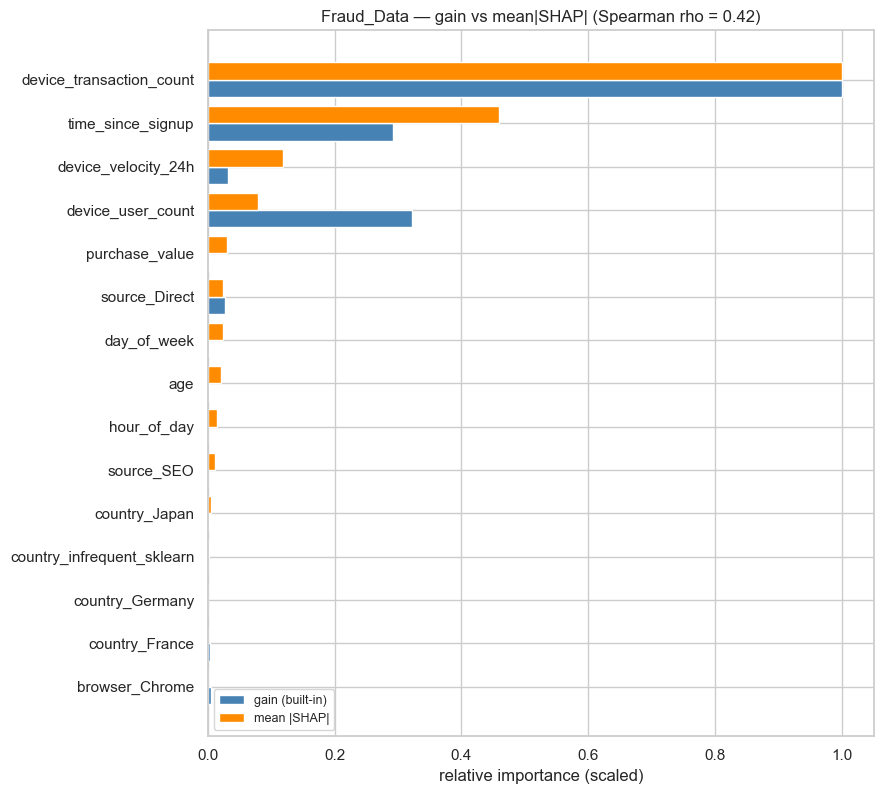

In [7]:
comparison = xai.importance_comparison(gain, shap_imp, top_n=15)
rho = xai.rank_correlation(gain, shap_imp)
print(f'Spearman rho(gain, mean|SHAP|) = {rho:.4f}')
display(comparison.round(4))
xai.plot_importance_comparison(comparison,
    f'Fraud_Data — gain vs mean|SHAP| (Spearman rho = {rho:.2f})',
    FIG / 'fraud_importance_comparison.png')
plt.show()

### The redundancy that explains most of the disagreement

`device_transaction_count` and `device_user_count` are ranked #1 and #2 by gain but #1 and #4 by SHAP. The check below shows why.

In [8]:
same = bool((fraud['device_transaction_count'] == fraud['device_user_count']).all())
print('device_transaction_count == device_user_count on every row:', same)
print('correlation:', round(float(fraud['device_transaction_count']
      .corr(fraud['device_user_count'])), 6))
print('\nuser_transaction_count distinct values:',
      fraud['user_transaction_count'].unique())
print('\nEvery user_id appears exactly once, so "transactions per device"')
print('and "distinct users per device" are the same column by construction.')
print('user_transaction_count is constant = 1: it carries zero information.')

device_transaction_count == device_user_count on every row: True
correlation: 1.0

user_transaction_count distinct values: [1]

Every user_id appears exactly once, so "transactions per device"
and "distinct users per device" are the same column by construction.
user_transaction_count is constant = 1: it carries zero information.


## 5. Local explanations — TP / FP / FN

Extremes are chosen deliberately: the highest-scoring caught fraud (clearest win), the highest-scoring legitimate row (worst false alarm), and the lowest-scoring missed fraud (hardest miss). Feature values are shown in **original units**, not standardised ones.

In [9]:
cases = xai.select_cases(y_test, scores, threshold)
display(xai.case_table(y_test, scores, threshold, cases))
raw = X_test.reset_index(drop=True)

,case,row,actual,fraud_score,predicted
0,true_positive,21684,1,0.999784,1
1,false_positive,26610,0,0.999668,1
2,false_negative,11806,1,0.076418,0
3,true_negative,11844,0,0.041028,0


TRUE POSITIVE — fraud score 0.9998


,feature,value,shap,direction
0,time_since_signup,0.0003,4.0411,toward fraud
1,device_velocity_24h,7.0000,2.2230,toward fraud
2,device_transaction_count,20.0000,1.9238,toward fraud
3,device_user_count,20.0000,0.1624,toward fraud
4,hour_of_day,6.0000,0.0275,toward fraud


raw values: {'time_since_signup': 0.0002777777777777, 'device_transaction_count': 20, 'device_velocity_24h': 7, 'purchase_value': 47, 'country': 'Saudi Arabia'}


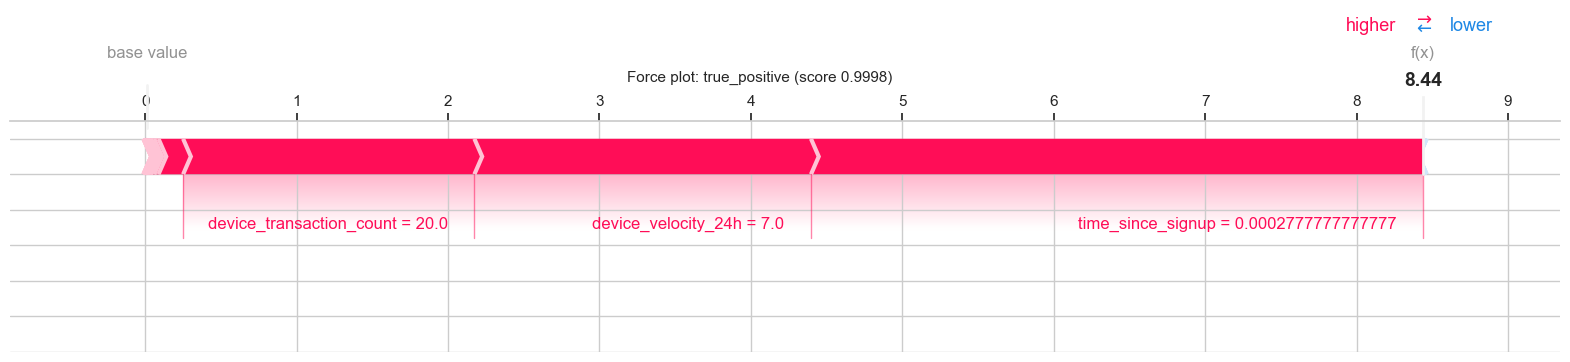

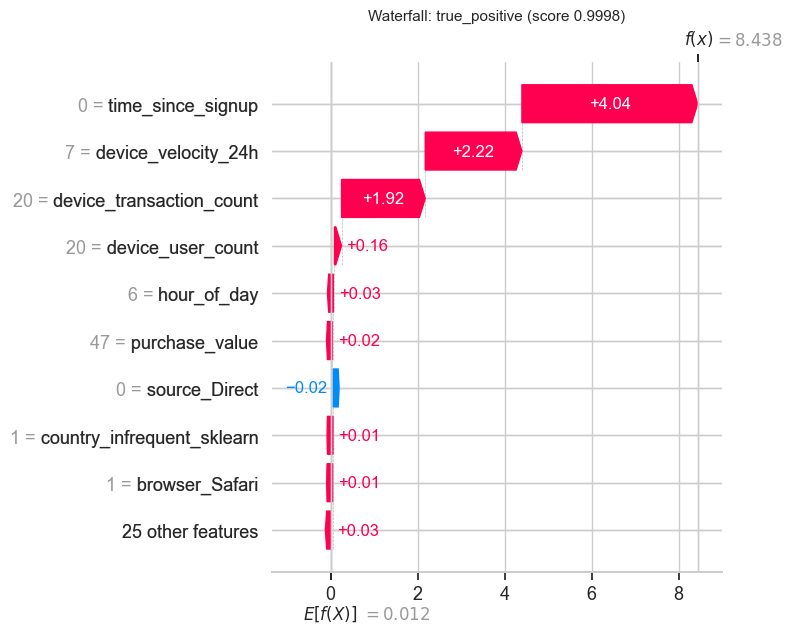

FALSE POSITIVE — fraud score 0.9997


,feature,value,shap,direction
0,time_since_signup,7.6164,3.9171,toward fraud
1,device_velocity_24h,7.0000,2.3449,toward fraud
2,device_transaction_count,7.0000,1.5899,toward fraud
3,device_user_count,7.0000,0.1185,toward fraud
4,source_Direct,1.0000,0.0752,toward fraud


raw values: {'time_since_signup': 7.616388888888889, 'device_transaction_count': 7, 'device_velocity_24h': 7, 'purchase_value': 21, 'country': 'United States'}


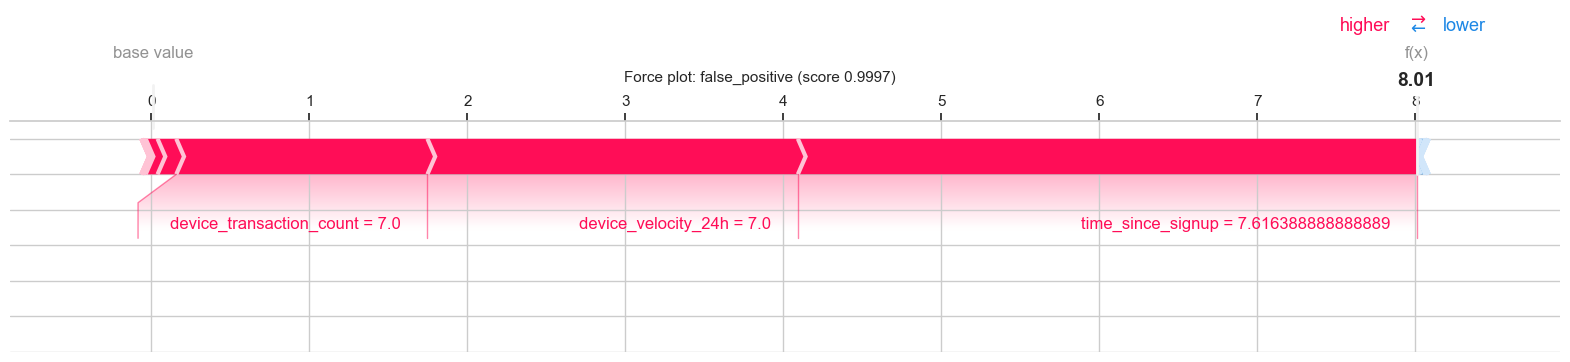

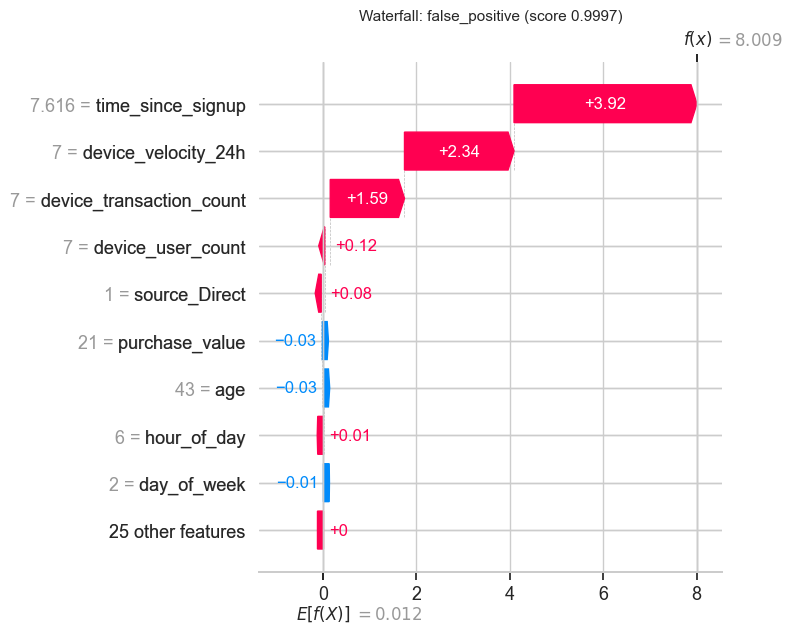

FALSE NEGATIVE — fraud score 0.0764


,feature,value,shap,direction
0,device_transaction_count,1.0000,-2.9344,toward legit
1,time_since_signup,4.7797,1.1136,toward fraud
2,device_user_count,1.0000,-0.3961,toward legit
3,purchase_value,18.0000,-0.1488,toward legit
4,country_infrequent_sklearn,0.0000,-0.1060,toward legit


raw values: {'time_since_signup': 4.779722222222222, 'device_transaction_count': 1, 'device_velocity_24h': 1, 'purchase_value': 18, 'country': 'United States'}


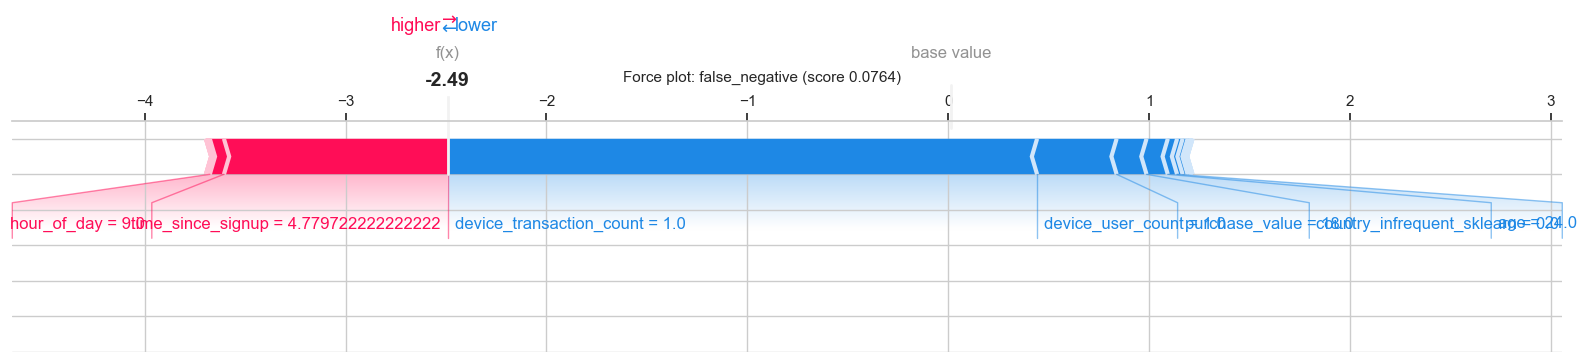

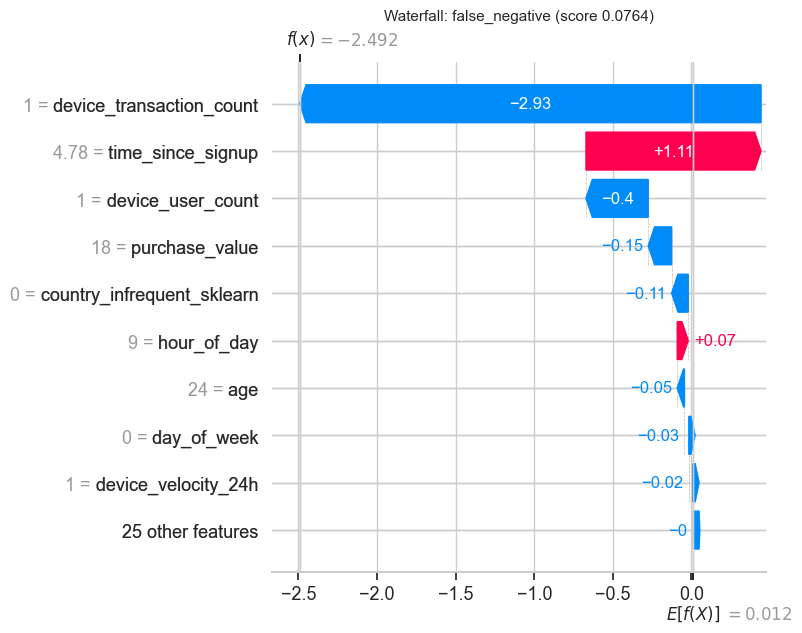

In [10]:
for name in ['true_positive', 'false_positive', 'false_negative']:
    pos = cases[name]
    print('=' * 78)
    print(f"{name.replace('_', ' ').upper()} — fraud score {scores[pos]:.4f}")
    display(xai.top_contributors(expl, pos, 5).round(4))
    print('raw values:', {k: raw.loc[pos, k] for k in
          ['time_since_signup', 'device_transaction_count',
           'device_velocity_24h', 'purchase_value', 'country']})
    xai.plot_force(expl, pos, f'Force plot: {name} (score {scores[pos]:.4f})',
                   FIG / f'fraud_force_{name}.png')
    plt.show()
    xai.plot_waterfall(expl, pos, 10,
                       f'Waterfall: {name} (score {scores[pos]:.4f})',
                       FIG / f'fraud_waterfall_{name}.png')
    plt.show()

### The instructive contrast

The false positive and the true negative have almost the **same** `time_since_signup` (~7.6 h). The device feature alone decides the outcome — which is the single clearest statement of what this model has learned.

In [11]:
rows = {n: cases[n] for n in ['false_positive', 'true_negative'] if n in cases}
display(pd.DataFrame({
    n: {**{k: raw.loc[p, k] for k in
            ['time_since_signup', 'device_transaction_count', 'device_velocity_24h']},
        'fraud_score': round(float(scores[p]), 4),
        'actual': int(y_test.to_numpy()[p])}
    for n, p in rows.items()}).round(3))

,false_positive,true_negative
time_since_signup,7.616,7.642
device_transaction_count,7.000,1.000
device_velocity_24h,7.000,1.000
fraud_score,1.000,0.041
actual,0.000,0.000


## 6. Effect shape — turning importance into thresholds

A ranking says *how much* a feature matters. To act on it you need to know *where* its effect switches sign.

SHAP effect of time_since_signup, and the actual fraud rate:


,n,mean_shap,direction,fraud_rate
time_since_signup,,,,
"(-1, 1]",1500,4.0370,toward fraud,0.9953
"(1, 6]",59,1.3373,toward fraud,0.0339
"(6, 24]",186,0.4004,toward fraud,0.0484
"(24, 168]",1406,-0.2748,toward legit,0.0548
"(168, 720]",5600,-0.2534,toward legit,0.0459
"(720, 1440]",7158,-0.2235,toward legit,0.0440
"(1440, 3000]",14314,-0.2370,toward legit,0.0473


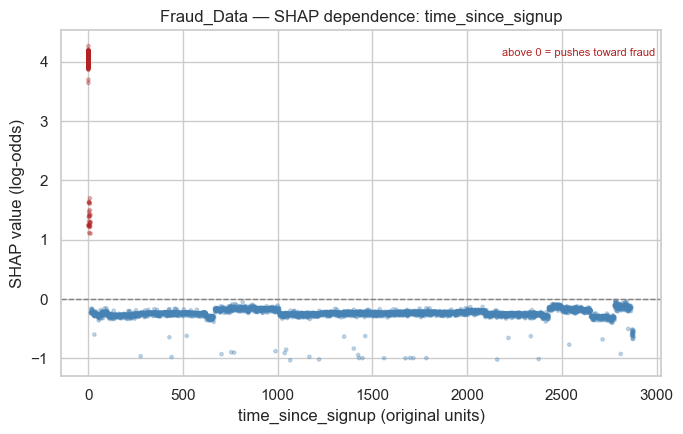

In [12]:
TSU_BINS = [-1, 1, 6, 24, 168, 720, 1440, 3000]  # hours: 1h/6h/1d/1w/1m/2m
shape = xai.effect_shape(expl, 'time_since_signup', bins=TSU_BINS)
shape['fraud_rate'] = (pd.DataFrame({'y': y_test.to_numpy(),
        'b': pd.cut(raw['time_since_signup'], bins=TSU_BINS)})
        .groupby('b', observed=True)['y'].mean())
print('SHAP effect of time_since_signup, and the actual fraud rate:')
display(shape.round(4))
xai.plot_dependence(plot_expl, 'time_since_signup',
    'Fraud_Data — SHAP dependence: time_since_signup',
    FIG / 'fraud_dependence_time_since_signup.png')
plt.show()

--- device_transaction_count ---


,n,mean_shap,direction,fraud_rate
device_transaction_count,,,,
1.0,26332,-0.8813,toward legit,0.0307
2.0,2188,1.1095,toward fraud,0.2340
3.0,52,1.4856,toward fraud,0.2500
4.0,2,1.7005,toward fraud,0.5000
5.0,17,1.6123,toward fraud,0.7059
6.0,34,1.4486,toward fraud,0.8824
7.0,63,1.4120,toward fraud,0.8571
8.0,118,1.5590,toward fraud,0.8983


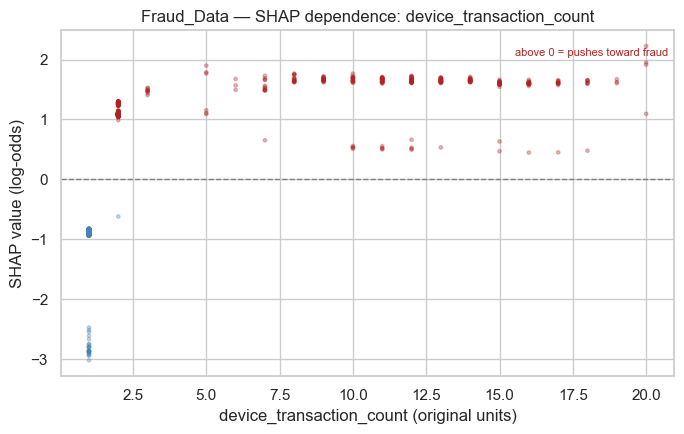

--- device_velocity_24h ---


,n,mean_shap,direction,fraud_rate
device_velocity_24h,,,,
1.0,28864,-0.0148,toward legit,0.0513
2.0,176,0.8056,toward fraud,0.9489
3.0,135,2.4546,toward fraud,1.0000
4.0,142,2.4571,toward fraud,1.0000
5.0,151,2.4559,toward fraud,1.0000
6.0,128,2.4622,toward fraud,1.0000
7.0,129,2.4659,toward fraud,0.9922
8.0,126,2.4653,toward fraud,1.0000


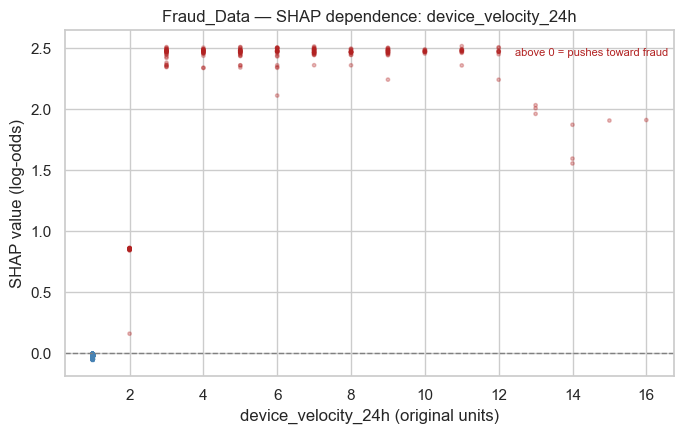

In [13]:
for feat in ['device_transaction_count', 'device_velocity_24h']:
    s = xai.effect_shape(expl, feat)
    s['fraud_rate'] = (pd.DataFrame({'y': y_test.to_numpy(), 'v': raw[feat]})
                       .groupby('v')['y'].mean())
    print(f'--- {feat} ---')
    display(s.head(8).round(4))
    xai.plot_dependence(plot_expl, feat,
        f'Fraud_Data — SHAP dependence: {feat}',
        FIG / f'fraud_dependence_{feat}.png')
    plt.show()

## 7. From SHAP thresholds to scored rules

Each SHAP threshold becomes a candidate rule, scored on the **full** dataset so the counts are stable. `precision` is how clean the flags are; `legit_flagged` is the customer-friction cost.

In [14]:
d, yf = fraud, fraud[config.FRAUD_TARGET]
rules = {
    'time_since_signup <= 1h': d['time_since_signup'] <= 1,
    'device_velocity_24h >= 2': d['device_velocity_24h'] >= 2,
    'device_transaction_count >= 2': d['device_transaction_count'] >= 2,
    'device_transaction_count >= 5': d['device_transaction_count'] >= 5,
    'tsu<=1h OR velocity>=2': (d['time_since_signup'] <= 1) | (d['device_velocity_24h'] >= 2),
    'tsu<=1h OR device_count>=2': (d['time_since_signup'] <= 1) | (d['device_transaction_count'] >= 2),
}
display(xai.rule_performance(yf, rules).round(4))

,rule,flagged,frauds_caught,legit_flagged,recall,precision
0,time_since_signup <= 1h,7641,7604,37,0.5373,0.9952
1,device_velocity_24h >= 2,6903,6854,49,0.4843,0.9929
2,device_transaction_count >= 2,19331,10141,9190,0.7166,0.5246
3,device_transaction_count >= 5,8391,7625,766,0.5388,0.9087
4,tsu<=1h OR velocity>=2,7704,7618,86,0.5383,0.9888
5,tsu<=1h OR device_count>=2,19368,10143,9225,0.7168,0.5237


### What the model cannot see

The rows no device/time rule reaches are the model's recall ceiling. Comparing fraud against legitimate traffic *within that region* shows whether more modelling could help.

In [15]:
uncovered = ~((d['time_since_signup'] <= 1) | (d['device_transaction_count'] >= 2))
cols = ['time_since_signup', 'device_transaction_count',
        'device_velocity_24h', 'purchase_value', 'age']
print(f'{int((uncovered & (yf == 1)).sum()):,} frauds '
      f'({(uncovered & (yf == 1)).sum() / yf.sum():.1%} of all fraud) sit here.')
display(pd.DataFrame({
    'fraud (uncovered)': d[uncovered & (yf == 1)][cols].median(),
    'legitimate (uncovered)': d[uncovered & (yf == 0)][cols].median(),
}).round(2))
print('The two columns are indistinguishable — this residual fraud is not')
print('reachable from these features, however the model is tuned.')

4,008 frauds (28.3% of all fraud) sit here.


,fraud (uncovered),legitimate (uncovered)
time_since_signup,1463.21,1444.01
device_transaction_count,1.00,1.00
device_velocity_24h,1.00,1.00
purchase_value,34.00,35.00
age,32.00,33.00


The two columns are indistinguishable — this residual fraud is not
reachable from these features, however the model is tuned.


## 8. creditcard — the same analysis on anonymised features

The features are PCA components, so no recommendation can name a business quantity. What SHAP still gives is *which* components carry the signal, and — usefully — what the misses have in common.

In [16]:
cc_art = joblib.load(config.MODELS_DIR / 'creditcard_selected.joblib')
cc_pipe, cc_thr = cc_art['pipeline'], cc_art['threshold']
cc_feats = list(cc_pipe.named_steps['preprocess'].feature_names_in_)
cc = pd.read_csv(config.CREDITCARD_CLEAN)
Xc, yc = md.split_features_target(cc, config.CREDITCARD_TARGET, cc_feats)
Xc_tr, Xc_te, yc_tr, yc_te = md.stratified_split(Xc, yc, test_size=0.2)
cc_scores = ev.predict_proba_positive(cc_pipe, Xc_te)
cc_gain = xai.builtin_importance(cc_pipe)
cc_expl = xai.shap_explanation(cc_pipe, Xc_te, sample_size=10000)
cc_shap = xai.shap_importance(cc_expl)
print(f'Spearman rho = {xai.rank_correlation(cc_gain, cc_shap):.4f}')
display(xai.importance_comparison(cc_gain, cc_shap, 10).round(4))

Spearman rho = 0.5560


,gain,mean_abs_shap,gain_rank,shap_rank,rank_gap
V14,0.5035,2.5452,1,1,0
V4,0.0603,1.7035,3,2,1
V12,0.0353,1.0548,4,3,1
V10,0.0811,0.8987,2,4,-2
V11,0.0157,0.7973,10,5,5
V3,0.0221,0.7413,7,6,1
V8,0.0298,0.5193,5,7,-2
V19,0.0243,0.4497,6,8,-2
V5,0.0076,0.3344,25,9,16
V1,0.0065,0.3304,28,10,18


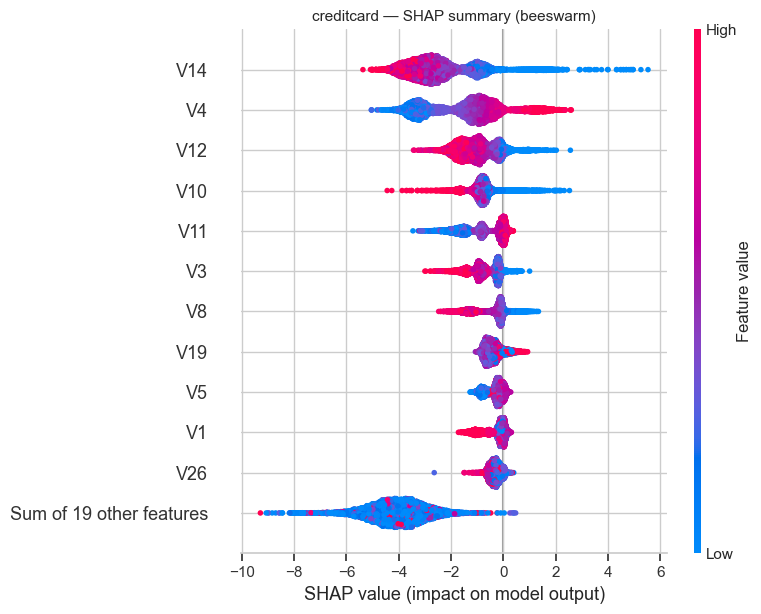

,case,row,actual,fraud_score,predicted
0,true_positive,18427,1,9.999986e-01,1
1,false_positive,33810,0,9.999899e-01,1
2,false_negative,5187,1,4.365927e-06,0
3,true_negative,8722,0,5.609086e-08,0


In [17]:
xai.plot_shap_summary(cc_expl, 12, 'creditcard — SHAP summary (beeswarm)',
    FIG / 'creditcard_shap_summary.png')
plt.show()
cc_cases = xai.select_cases(yc_te, cc_scores, cc_thr)
display(xai.case_table(yc_te, cc_scores, cc_thr, cc_cases))

In [18]:
# What do the missed frauds have in common? Amount is the one feature
# here that carries business meaning.
cc_raw = Xc_te.reset_index(drop=True)
yt = yc_te.to_numpy(); pred = cc_scores >= cc_thr
missed, caught = (yt == 1) & ~pred, (yt == 1) & pred
display(pd.DataFrame({
    'missed fraud': cc_raw['Amount'][missed].describe()[['count', '50%', 'mean']],
    'caught fraud': cc_raw['Amount'][caught].describe()[['count', '50%', 'mean']],
    'legitimate': cc_raw['Amount'][yt == 0].describe()[['count', '50%', 'mean']],
}).round(2))
f_all = cc[cc[config.CREDITCARD_TARGET] == 1]
l_all = cc[cc[config.CREDITCARD_TARGET] == 0]
print(f"full data — share of fraud with Amount <= $1: {(f_all['Amount'] <= 1).mean():.1%}")
print(f"full data — share of legit with Amount <= $1: {(l_all['Amount'] <= 1).mean():.1%}")

,missed fraud,caught fraud,legitimate
count,22.00,73.00,56651.0
50%,2.99,33.59,21.6
mean,173.25,150.06,88.7


full data — share of fraud with Amount <= $1: 36.2%
full data — share of legit with Amount <= $1: 10.6%


## 9. Interpretation and recommendations

The written interpretation, the top-5 driver discussion, the counterintuitive findings and the full recommendation list are in **[`reports/task3-report.md`](../reports/task3-report.md)**.

Headline findings:

1. **Three drivers, not five.** `device_transaction_count`, `time_since_signup` and `device_velocity_24h` carry ~97% of total mean |SHAP|. Ranks 4–5 are a duplicate column and a noise-level feature.
2. **The effect is a cliff, not a gradient.** Purchases within 1 hour of signup are 99.5% fraud; past that hour the fraud rate returns to baseline immediately.
3. **Two engineered features were redundant or dead** — `device_user_count` is identical to `device_transaction_count`, and `user_transaction_count` is constant at 1.
4. **The model is a smoothed rule engine.** Two hard rules reproduce its precision/recall almost exactly, which bounds what the ensemble adds on this dataset.
5. **28% of fraud is unreachable** from these features — the uncovered region is statistically identical to legitimate traffic.